# PandaX-4T ER analysis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm


## Loading PandaX-4T data

In [2]:
# Energy range 1- 30 keVee 
PXdata = np.genfromtxt('../data/exps/pandaX/ER2024/run1_evts.csv', skip_header=1, delimiter=',')

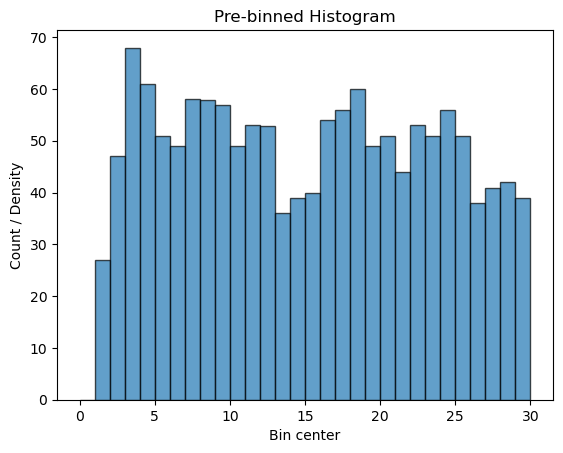

In [3]:
# Assuming your loaded array is called 'data'
bin_centers = PXdata[:, 0]   # column 1: bin centers (or edges)
heights = PXdata[:, 1]       # column 2: counts/density

# If column 1 is bin CENTERS, you need the width:
# Option A: Assume uniform width from spacing
bin_width = bin_centers[1] - bin_centers[0]  # if uniform spacing

plt.bar(bin_centers, heights, width=bin_width, 
        edgecolor='black', alpha=0.7, align='center')
plt.xlabel('Bin center')
plt.ylabel('Count / Density')
plt.title('Pre-binned Histogram')
plt.show()

## Loading PandaX-4T backgrounds

In [4]:
# Energy range 1- 30 keVee 
PXbkg = np.genfromtxt('../data/exps/pandaX/ER2024/run1_bkg.csv', skip_header=1, delimiter=',')

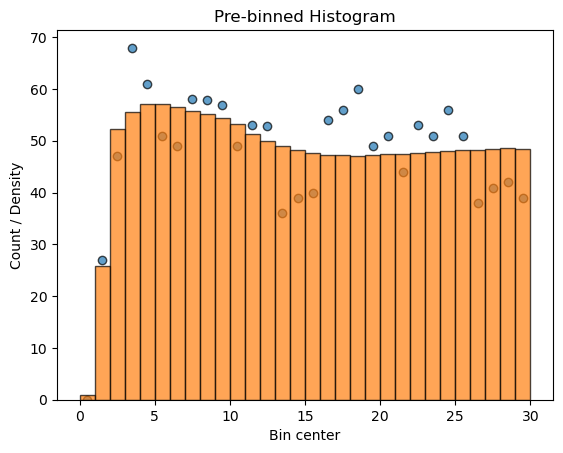

In [5]:
plt.scatter(PXdata[:, 0], PXdata[:, 1], 
        edgecolor='black', alpha=0.7)
plt.bar(PXbkg[:, 0], PXbkg[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center')
plt.xlabel('Bin center')
plt.ylabel('Count / Density')
plt.title('Pre-binned Histogram')
plt.show()

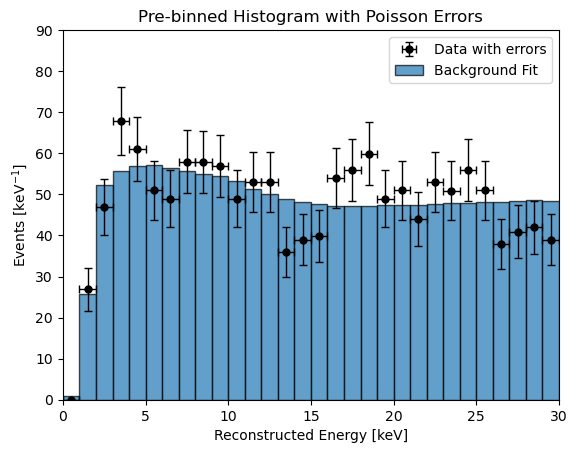

In [6]:
y_err = np.sqrt(heights)

# X-error: half bin width on each side (so bars span the full bin)
x_err = bin_width / 2

# Plot with error bars
plt.errorbar(bin_centers, heights, 
             xerr=x_err, yerr=y_err,
             fmt='o',              # marker style (like scatter)
             capsize=3,            # cap size on error bars
             capthick=1,           # cap thickness
             elinewidth=1,         # error bar line width
             markersize=5,
             label='Data with errors',
             color='black')

# Your fit curve
plt.bar(PXbkg[:, 0], PXbkg[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label='Background Fit')

plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
plt.ylim(0,90)
plt.xlim(0.0,30.0)
plt.title('Pre-binned Histogram with Poisson Errors')
plt.legend()
plt.show()

#### Produce the signal 

In [7]:
from snudd import config
from snudd.targets import Electron      # the elctron target class object
from snudd.binding import binding_xe   # dataclass of binding energy data for xenon and argon
from snudd.rrpa    import rrpa_scaling  # ad-hoc rrpa scaling for bound electron
from snudd.models  import GeneralNSI, SM    # Generic NSI model
from snudd.targets import Nucleus       # Still need a nucleus to be declared

### Build efficiency & resolution

In [8]:
from snudd import config
from snudd.efficiencies import Efficiency
from snudd.resolution   import Resolution, Convolver, resolution_pandaX
from snudd.quenching import quenching_electron


PX_EFF_R1 = np.loadtxt(config.get_data("exps/pandaX/ER2024/efficiency_ER_run1.csv"), delimiter=",", skiprows=1, unpack=True)
efficiency_er_px = Efficiency(PX_EFF_R1)
res_panda_er = Resolution(resolution_pandaX, efficiency_er_px, quenching_electron)

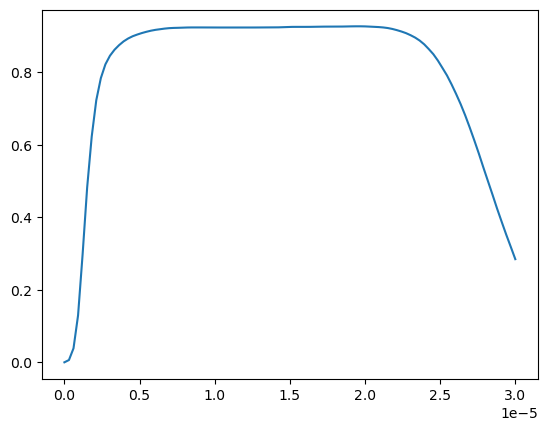

In [9]:
ERtest = np.linspace(0, 30, 100) * 1e-6  # Convert keV to GeV

plt.plot(ERtest, efficiency_er_px(ERtest), label='Efficiency')


In [10]:
# Setting up the SM
sm_model = SM()

The exposure for LZ WS2024 is $363.3\,{\rm tonne ⋅ day}$ for Run1

In [16]:
# Recoil energy in GeV, needed for the convolution to be broader than the bin considered
E_Rs = np.logspace(-2, 2, 1000) / 1e6  



Xe_nucleus = Nucleus(54, 132, mass=131.9041535 * config.u) # only do one isotope for this example 


Xe_electron = Electron(Xe_nucleus, binding_xe, rrpa_scaling) 
Xe_electron.update_model(sm_model)
Xe_electron.prepare_density()

sm_spec_xe = Xe_electron.spectrum(E_Rs) 

def counts_PX_ER(signal, E_Rs, E1, E2):
    exposure = 363.3/365 # in tn yr-1
    convolution_PX_sig= Convolver(E_Rs, signal , efficiency_er_px, res_panda_er)
    
    return convolution_PX_sig.convolved_binned_rate(E1, E2)*exposure



In [17]:
bin_centers = PXdata[:, 0]   # column 1: bin centers (or edges)
counts_PX_ER(sm_spec_xe, E_Rs, (bin_centers[0]- bin_width/2)*1e-6, (bin_centers[0] + bin_width/2)*1e-6)

np.float64(0.1951761065333421)

In [18]:
counts_sm = [
    (counts_PX_ER(
        sm_spec_xe,
        E_Rs,
        (bc - bin_width / 2) * 1e-6,
        (bc + bin_width / 2) * 1e-6
    )).real
    for bc in bin_centers
]

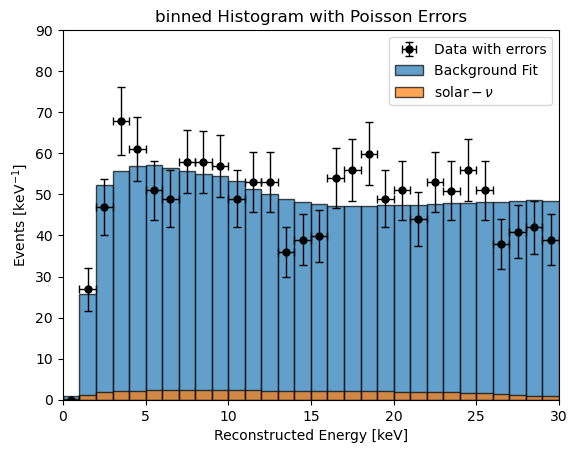

In [19]:
y_err = np.sqrt(heights)

# X-error: half bin width on each side (so bars span the full bin)
x_err = bin_width / 2

# Plot with error bars
plt.errorbar(bin_centers, heights, 
             xerr=x_err, yerr=y_err,
             fmt='o',              # marker style (like scatter)
             capsize=3,            # cap size on error bars
             capthick=1,           # cap thickness
             elinewidth=1,         # error bar line width
             markersize=5,
             label='Data with errors',
             color='black')

# Your fit curve
plt.bar(PXbkg[:, 0], PXbkg[:, 1], width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label='Background Fit')

plt.bar(bin_centers, counts_sm, width=bin_width, 
        edgecolor='black', alpha=0.7, align='center', label=r'${\rm solar-}\nu$')

plt.xlabel(r'Reconstructed Energy [keV]')
plt.ylabel(r'Events [keV$^{-1}$]')
plt.ylim(0,90)
plt.xlim(0.0,30.0)
plt.title('binned Histogram with Poisson Errors')
plt.legend()
plt.show()

In [20]:
# Integrate the theoretical spectrum
ERtest = np.linspace(0, 30, 100) * 1e-6  # Convert keV to GeV
sm_spec_xe = Xe_electron.spectrum(ERtest)
# plt.plot(ERtest, sm_spec_xe)

print("SM counts (w/o detector effects):", np.trapezoid(sm_spec_xe, x=ERtest*1e6))
print("SM counts (w/  detector effects):", sum(counts_sm))

SM counts (w/o detector effects): 69.20602312385392
SM counts (w/  detector effects): 55.847960293412946


Note, that without RRPA we match their results quite well ($72.6\pm8.1$)

## Statistical analysis

This best-fit background includes the solar-$\nu$ background. Assuming out  

In [28]:
# Pop first bkg entry - no data point
bkg_nucor = PXbkg[:, 1] - counts_sm

We want to calculate the total rate including a NSI signal, for the ith bin

$$N_{\rm pred}^{i}(\Theta; \alpha)= (1+\alpha)N_{\rm bkg}^{i} + N^i_{\rm NSI}(\Theta)$$

where $\Theta$ is the NSI parameters and $\alpha$ is the nuisance parameter of the background fit. 

Can define the $\chi^2$ as 

$$\chi^2=2\sum^{\rm bins}_{i=1}\left[N_{\rm pred}^i-N_{\rm data}^{i} + N_{\rm data}^i\ln\left(\frac{N_{\rm data}^i}{N_{\rm pred}^i}\right)\right] + \left(\frac{\alpha}{\sigma_{\alpha}}\right)^2$$

So we need to understand the error in the background

In [21]:
# Run1 fit results from 2408.07641: (central_value, error) 
bkg_run1 = {
    "Tritium":          (118.4, 31.1),
    "Pb214":            (700.3, 45.3),
    "Pb212":            (96.5, 23.8),
    "Kr85":             (272.2, 58.9),
    "Material":         (105.9, 7.8),
    "Xe136":            (62.3, 4.6),
    "Xe127":            (0, 0),
    "Xe124":            (3.9, 1.1),
    "Accidental":       (7.0, 1.9) #, "solar_nu_ER": (72.6 ± 8.1),
}


In [22]:
def total_background(components: dict):
    values = np.array([v for v, _ in components.values()])
    errors = np.array([e for _, e in components.values()])
    total_val = values.sum()
    total_err = np.sqrt((errors**2).sum())  # quadrature sum
    return total_val, total_err

total_val_run1, total_err_run1 = total_background(bkg_run1)

print(f"Total background: {total_val_run1:.1f} ± {total_err_run1:.1f}")

Total background: 1366.5 ± 84.5


In [23]:
rel_unc = total_err_run1/total_val_run1 
print(rel_unc)

0.06184339085563942


In [24]:
def poisson_chi2(N_nu: np.ndarray, N_bkg: np.ndarray, N_data: np.ndarray, alpha: float = 0.0, sigma_alpha: float = 1.0):
    """
    Compute the Poissonlikelihood-based chi-squared (Cash statistic).

    chi^2 = 2 * sum_i [ N_pred^i - N_data^i + N_data^i * ln(N_data^i / N_pred^i) ] + (alpha / sigma_alpha)^2

    Parameters
    ----------
    N_nu : np.ndarray
        Number of neutrino events in each bin (must be non-negative)
    N_bkg : np.ndarray
        Number of background events in each bin (must be non-negative)
    N_data : np.ndarray
        Observed number of events in each bin (must be non-negative)
    alpha : float, optional
        Nuisance parameter (default: 0.0)
    sigma_alpha : float, optional
        Uncertainty on the nuisance parameter (default: 1.0)

    Returns
    -------
    float
        The chi-squared value
    """
    N_pred = np.atleast_1d(N_nu + (1+alpha)*N_bkg)
    N_data = np.atleast_1d(N_data)

    assert len(N_pred) == len(N_data), "N_pred and N_data must have the same length"

    # Handle edge cases:
    # 1. When N_data = 0, the term N_data * ln(N_data / N_pred) -> 0 (limit as x->0 of x*ln x = 0)
    # 2. When N_pred = 0, the log term is problematic - skip these bins
    # 3. Use np.log to compute ln(N_data / N_pred) = ln(N_data) - ln(N_pred)

    valid_mask = N_pred > 0

    if not np.any(valid_mask):
        return np.inf  # all predictions are invalid

    N_pred_valid = N_pred[valid_mask]
    N_data_valid = N_data[valid_mask]

    # Compute term = N_pred - N_data + N_data * ln(N_data / N_pred)
    # For zero bins where N_data = 0, the ln term contributes zero
    term = N_pred_valid - N_data_valid + N_data_valid * (
        np.log(N_data_valid + 1e-300) - np.log(N_pred_valid)  # handles N_data = 0 naturally
    )

    # Sum over bins and multiply by 2
    chi2 = 2.0 * np.sum(term)

    # Add the nuisance parameter penalty term
    chi2 += (alpha / sigma_alpha)**2

    return chi2

In [29]:
poisson_chi2(counts_sm, bkg_nucor, heights)

np.float64(29.685418945072602)

####  1D scan 

In [30]:
eps_space = np.geomspace(1e-1, 1, 20)
eta = 0.0 # therefore in the proton-neutron plane
phi = np.pi/2 # therefore in the electron direction   




In [31]:
from snudd.nsi import utils

def set_NSI_params(eps, eta, phi):
    
    eps_matrix = np.array([[0., 1.0, 0.], [1.0, 0.0, 0.], [0., 0, 0.0]]) * eps # eps_{e\mu} can change this structure 
    eps_matrix = utils.eps_matrix_sym(eps_matrix)
    nsi_model = GeneralNSI(eps_matrix, eta, phi)
    
    return nsi_model

In [33]:
# Initialize a 2D array: shape (n_eps, n_bins)
counts_all = np.zeros((len(eps_space), len(bin_centers)))

for i, eps in enumerate(tqdm(eps_space, desc="Processing eps values")):
    NSI_eps_tmp = eps
    NSI_eta_tmp = eta  # fixed as zero
    NSI_phi_tmp = phi  # fixed as zero

    nsi_temp = set_NSI_params(NSI_eps_tmp, NSI_eta_tmp, NSI_phi_tmp)
    Xe_electron.update_model(nsi_temp)
    Xe_electron.prepare_density()

    signal_temp = Xe_electron.spectrum(E_Rs) 
    # Compute binned counts for this eps value
    counts_all[i, :] = np.array([
        (counts_PX_ER(
            np.array(signal_temp),
            E_Rs,
            (bc - bin_width / 2) * 1e-6,
            (bc + bin_width / 2) * 1e-6
        )).real
        for bc in bin_centers
    ])


Processing eps values: 100%|██████████| 20/20 [00:10<00:00,  1.90it/s]


In [34]:
counts_all[1, :]

array([0.24555411, 1.41580041, 2.2573691 , 2.5356069 , 2.73143286,
       2.95969483, 3.08488044, 3.10687863, 3.0994934 , 3.08714961,
       3.0737936 , 3.06046431, 3.0475581 , 3.03522765, 3.02338091,
       3.01166332, 2.99961253, 2.98658118, 2.97112373, 2.95012217,
       2.91804607, 2.86662234, 2.78529343, 2.66293573, 2.49092121,
       2.26668925, 1.99625356, 1.69426311, 1.3813162 , 1.07947585])

In [35]:
chi2_values = np.zeros(len(eps_space)) 

for i in range(len(eps_space)):
    chi2_values[i] = poisson_chi2(counts_all[i, :], bkg_nucor, heights)

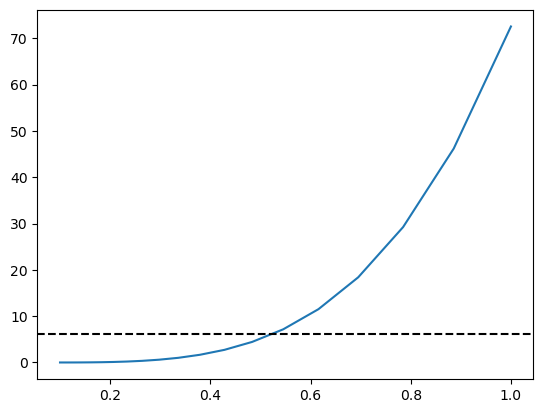

In [105]:
plt.plot(eps_space, chi2_values-np.min(chi2_values))
plt.axhline(6.18, color='k', ls='--')


To marginalize over the nuisance $\alpha$ I need to minimize the $\chi^2$ w.r.t. $\alpha$ 

In [36]:
from scipy.optimize import minimize_scalar


In [37]:
minimize_scalar(fun = lambda a: poisson_chi2(counts_all[i, :], bkg_nucor, heights, alpha=a, sigma_alpha=rel_unc), bounds=(-5, 5), method='bounded')

 message: Solution found.
 success: True
  status: 0
     fun: 43.08341856944609
       x: -0.21508263837242525
     nit: 13
    nfev: 13

In [38]:
chi2_alpha_values = np.zeros(len(eps_space)) 

for i in range(len(eps_space)):
    result = minimize_scalar(fun = lambda a: poisson_chi2(counts_all[i, :], bkg_nucor, heights, alpha=a, sigma_alpha=0.0364), bounds=(-5, 5), method='bounded')
    chi2_alpha_values[i] = result.fun

Text(0, 0.5, '$\\chi^2 - \\chi^2_{\\rm min}$')

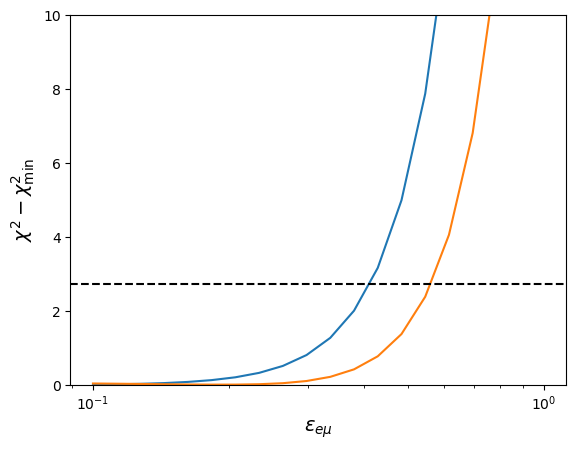

In [39]:
plt.semilogx(eps_space, chi2_values-np.min(chi2_values))
plt.semilogx(eps_space, chi2_alpha_values-np.min(chi2_alpha_values))

plt.axhline(2.71, color='k', ls='--')

plt.ylim(0, 10)
plt.xlabel(r'$\epsilon_{e\mu}$', size=14)
plt.ylabel(r'$\chi^2 - \chi^2_{\rm min}$', size=14)